# Cancer Dataset: Synthetic Data Quality Assessment with Mahalanobis Distance

This notebook:
1. Loads the **Cancer** dataset and prepares it for synthesis.
2. Generates synthetic data using **SDV** models: **CTGAN**, **CopulaGAN**, **Gaussian Copula**, and **TVAE**.
3. Assesses synthetic data quality using **Mahalanobis distance** (distribution-based and optional pairwise matching: **Hungarian** optimal and **Greedy** one-to-one).

**Mahalanobis distance** measures how far a point is from a distribution in terms of standard deviations, accounting for correlations between features. Lower distances indicate synthetic samples that are closer to the real data distribution.

## 1. Data loading and preparation

In [1]:
import warnings
import numpy as np
import pandas as pd
warnings.filterwarnings('ignore')

# Path to Cancer dataset: find project root (folder containing 'Datasets')
import os
cwd = os.getcwd()
candidates = [cwd, os.path.join(cwd, '..'), os.path.join(cwd, '..', '..')]
ROOT = cwd
for c in candidates:
    p = os.path.abspath(c)
    if os.path.isdir(os.path.join(p, 'Datasets')):
        ROOT = p
        break
DATA_PATH = os.path.join(ROOT, "Datasets", "Cancer.csv")

cancer_data = pd.read_csv(DATA_PATH)
cancer_data.drop(['id', 'Unnamed: 32'], axis=1, inplace=True, errors='ignore')
# Use numeric features only for Mahalanobis (drop diagnosis for distance computation)
data = cancer_data.drop(columns=['diagnosis'], errors='ignore')

print(f"Data shape: {data.shape}")
print(f"Columns: {list(data.columns)}")
data.info()

Data shape: (569, 30)
Columns: ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   radius_mean              569 non-null    float64
 1   texture_mean             569 non-null    float64
 2   perimeter_mean           569 non-null    float64
 3   area_mean                569 non-null    fl

In [2]:
import sdv
from sdv.metadata import SingleTableMetadata

# For SDV we use full table (with diagnosis as numeric for consistency with other notebooks)
cancer_sdv = cancer_data.copy()
cancer_sdv.replace({'diagnosis': {'M': 1, 'B': 0}}, inplace=True)

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(cancer_sdv)

# Numeric-only dataframe for Mahalanobis (same 30 columns as in cosine assessment)
feature_cols = [c for c in data.columns]
data_numeric = data.astype(float)
print(f"Numeric feature matrix shape: {data_numeric.shape}")

Numeric feature matrix shape: (569, 30)


## 2. SDV models: fit and sample

We fit **CTGAN**, **CopulaGAN**, **Gaussian Copula**, and **TVAE** on the full Cancer table (with diagnosis), then sample the same number of rows as the real data. Mahalanobis is computed on the numeric feature columns only.

In [3]:
from sdv.single_table import (
    GaussianCopulaSynthesizer,
    CTGANSynthesizer,
    CopulaGANSynthesizer,
    TVAESynthesizer,
)

models = {
    "GaussianCopula": GaussianCopulaSynthesizer(metadata=metadata),
    "CTGAN": CTGANSynthesizer(metadata=metadata),
    "CopulaGAN": CopulaGANSynthesizer(metadata=metadata),
    "TVAE": TVAESynthesizer(metadata=metadata),
}

for name, model in models.items():
    print(f"Fitting {name}...")
    model.fit(cancer_sdv)

print("All models fitted!")

Fitting GaussianCopula...
Fitting CTGAN...
Fitting CopulaGAN...
Fitting TVAE...
All models fitted!


In [4]:
# Synthetic sample size = real data sample size (required for one-to-one Hungarian matching)
n_rows = len(cancer_sdv)
synthetic_data = {}

for name, model in models.items():
    synthetic_data[name] = model.sample(num_rows=n_rows)
    # Align columns to numeric features only (drop diagnosis if present for distance)
    synth_numeric = synthetic_data[name][feature_cols].astype(float)
    synthetic_data[name + "_numeric"] = synth_numeric

print(f"Real data size: {n_rows}. Sampled {n_rows} synthetic rows per model (same as real).")
print("Sample (GaussianCopula):")
display(synthetic_data["GaussianCopula"].head())

Real data size: 569. Sampled 569 synthetic rows per model (same as real).
Sample (GaussianCopula):


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,0,13.063,18.07,82.27,534.0,0.07895,0.04268,0.022739,0.019326,0.1457,...,13.945,25.23,89.44,596.3,0.12997,0.09224,0.102124,0.081370,0.2130,0.07473
1,0,12.903,16.68,83.22,511.3,0.11140,0.13874,0.046816,0.024106,0.2176,...,14.824,25.43,95.36,703.1,0.15198,0.39831,0.219331,0.114531,0.3815,0.10816
2,0,12.144,20.38,79.67,440.2,0.10578,0.15952,0.087810,0.037386,0.2042,...,14.063,31.96,92.47,597.6,0.14872,0.43640,0.252768,0.146417,0.4024,0.10780
3,1,11.171,20.74,71.76,381.8,0.10040,0.08525,0.028174,0.021851,0.1560,...,11.366,27.09,72.87,399.3,0.13801,0.13753,0.049883,0.047761,0.2118,0.07572
4,1,28.110,25.93,188.50,2425.7,0.08694,0.08802,0.138158,0.094686,0.1234,...,36.040,36.42,251.20,3947.7,0.14332,0.26353,0.408867,0.214969,0.1913,0.07765


## 4. Mahalanobis distance: setup

We estimate the **mean** and **covariance** of the real data (numeric features), then compute Mahalanobis distance for each synthetic sample to this distribution:

$$d_M(x) = \sqrt{(x - \mu)^T \Sigma^{-1} (x - \mu)}$$

If the covariance is singular, we add a small regularization (ridge) so that $\Sigma + \lambda I$ is invertible.

In [5]:
from numpy.linalg import inv, LinAlgError

def fit_mahalanobis_params(real_matrix, reg=1e-6):
    """
    Compute mean and inverse covariance for Mahalanobis distance.
    real_matrix: (n_samples, n_features) array.
    Returns: mean (1D), inv_cov (2D).
    """
    mu = np.mean(real_matrix, axis=0)
    cov = np.cov(real_matrix, rowvar=False)
    # Ensure shape (p,p) when n_samples small
    if cov.ndim == 0:
        cov = np.array([[cov]])
    p = cov.shape[0]
    try:
        inv_cov = inv(cov + reg * np.eye(p))
    except LinAlgError:
        inv_cov = inv(cov + (reg * 10) * np.eye(p))
    return mu, inv_cov

def mahalanobis_distances_to_distribution(synth_matrix, mu, inv_cov):
    """
    For each row in synth_matrix, compute Mahalanobis distance to distribution (mu, inv_cov).
    Returns 1D array of length synth_matrix.shape[0].
    """
    delta = synth_matrix - mu
    # d_i^2 = (x_i - mu)^T inv_cov (x_i - mu)
    d2 = np.einsum('ij,jk,ik->i', delta, inv_cov, delta)
    return np.sqrt(np.maximum(d2, 0))

# Fit on real data (no scaling)
real_matrix = data_numeric.to_numpy()
mu_real, inv_cov_real = fit_mahalanobis_params(real_matrix)
print("Fitted mean and inverse covariance on real data.")
print(f"Mean shape: {mu_real.shape}, Inv_cov shape: {inv_cov_real.shape}")

Fitted mean and inverse covariance on real data.
Mean shape: (30,), Inv_cov shape: (30, 30)


## 5. Quality assessment: Mahalanobis distance per model

For each synthetic dataset we compute the Mahalanobis distance of every synthetic sample to the **real** distribution, then report mean, median, and std. **Lower** values indicate better fidelity to the real distribution.

In [6]:
mahalanobis_results = {}

for name in ["GaussianCopula", "CTGAN", "CopulaGAN", "TVAE"]:
    synth_numeric = synthetic_data[name + "_numeric"].to_numpy()
    dists = mahalanobis_distances_to_distribution(synth_numeric, mu_real, inv_cov_real)
    mahalanobis_results[name] = {
        "mean": float(np.mean(dists)),
        "median": float(np.median(dists)),
        "std": float(np.std(dists)),
        "min": float(np.min(dists)),
        "max": float(np.max(dists)),
        "distances": dists,
    }

# Summary table
summary = pd.DataFrame({
    name: [r["mean"], r["median"], r["std"], r["min"], r["max"]]
    for name, r in mahalanobis_results.items()
}, index=["mean_dist", "median_dist", "std_dist", "min_dist", "max_dist"]).T
summary.index.name = "Model"
print("Mahalanobis distance to real distribution (lower is better):")
display(summary)

Mahalanobis distance to real distribution (lower is better):


,mean_dist,median_dist,std_dist,min_dist,max_dist
Model,,,,,
GaussianCopula,6.532506,6.202199,1.902008,3.026164,18.537426
CTGAN,138.775700,127.245752,67.628975,26.086226,381.417417
CopulaGAN,119.135544,102.512265,65.195943,22.226075,349.695705
TVAE,41.646112,33.262255,29.051944,7.077958,174.307140


## 6. Visualization: distribution of Mahalanobis distances

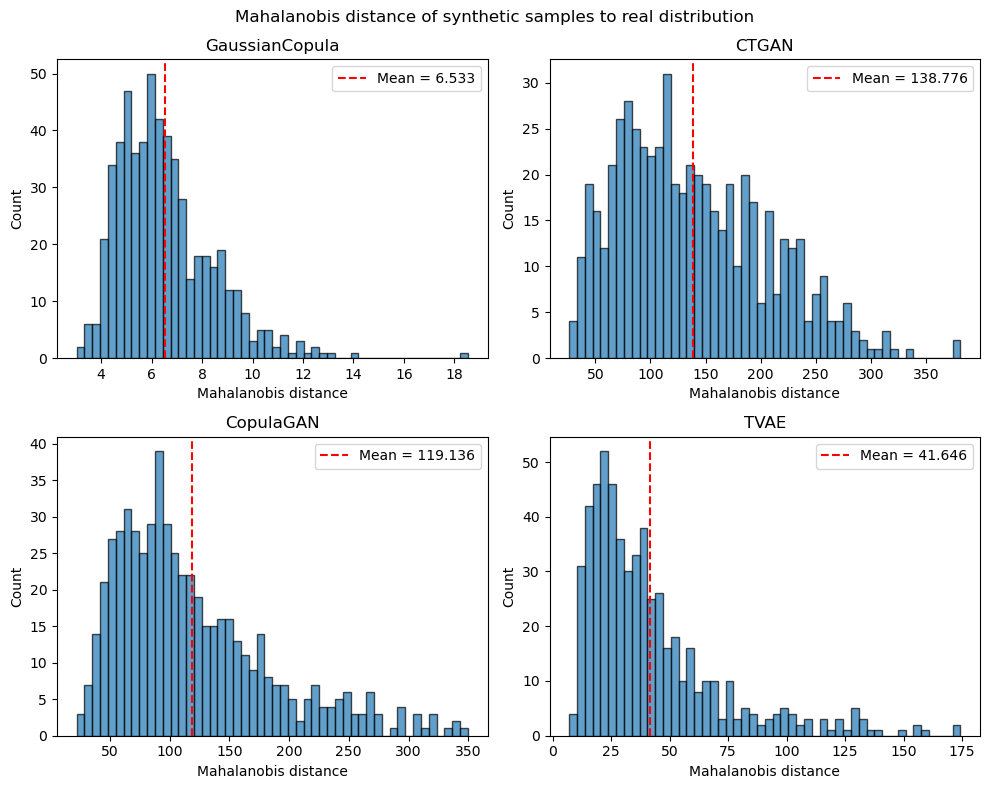

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()
for ax, (name, res) in zip(axes, mahalanobis_results.items()):
    ax.hist(res["distances"], bins=50, edgecolor='black', alpha=0.7)
    ax.axvline(res["mean"], color='red', linestyle='--', label=f"Mean = {res['mean']:.3f}")
    ax.set_title(name)
    ax.set_xlabel("Mahalanobis distance")
    ax.set_ylabel("Count")
    ax.legend()
plt.suptitle("Mahalanobis distance of synthetic samples to real distribution", fontsize=12)
plt.tight_layout()
os.makedirs(os.path.join(ROOT, "figures"), exist_ok=True)
plt.savefig(os.path.join(ROOT, "figures", "mahalanobis_cancer_by_model.png"), dpi=150, bbox_inches='tight')
plt.show()

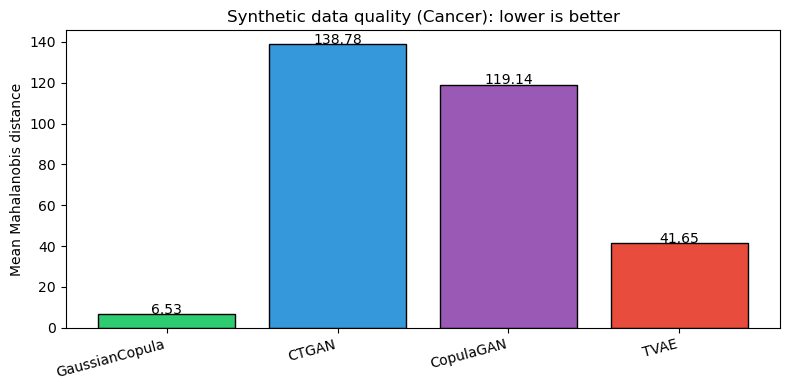

In [8]:
# Bar plot: mean Mahalanobis distance by model
fig, ax = plt.subplots(figsize=(8, 4))
models_order = ["GaussianCopula", "CTGAN", "CopulaGAN", "TVAE"]
means = [mahalanobis_results[m]["mean"] for m in models_order]
colors = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c']
bars = ax.bar(models_order, means, color=colors, edgecolor='black')
ax.set_ylabel("Mean Mahalanobis distance")
ax.set_title("Synthetic data quality (Cancer): lower is better")
ax.set_xticklabels(models_order, rotation=15, ha='right')
for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f"{val:.2f}", ha='center', fontsize=10)
plt.tight_layout()
os.makedirs(os.path.join(ROOT, "Mahalanobis_distance", "Cancer", "figures"), exist_ok=True)
plt.savefig(os.path.join(ROOT, "Mahalanobis_distance", "Cancer", "figures", "mahalanobis_mean_by_model.png"), dpi=150, bbox_inches='tight')
plt.show()

## 7. Hungarian algorithm: optimal one-to-one matching (Mahalanobis as distance)

We treat **Mahalanobis distance** as the distance between each real and each synthetic sample. The **Hungarian algorithm** finds the optimal one-to-one matching that **minimizes total distance** (sum of matched Mahalanobis distances). We report total distance and mean distance per match for each model.

In [9]:
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

def pairwise_mahalanobis(real_matrix, synth_matrix, inv_cov):
    """
    Compute pairwise Mahalanobis distances.
    real_matrix: (n x p)
    synth_matrix: (n x p)
    inv_cov: (p x p) from REAL data
    """
    return cdist(real_matrix, synth_matrix, metric="mahalanobis", VI=inv_cov)

In [10]:
# Hungarian matching: use full real and synthetic data (same size n_rows)
hungarian_results = {}

n_samples = len(real_matrix)  # real and synthetic both have this many rows

for name in ["GaussianCopula", "CTGAN", "CopulaGAN", "TVAE"]:
    synth_numeric = synthetic_data[name + "_numeric"].to_numpy()
    assert synth_numeric.shape[0] == n_samples, f"Synthetic size {synth_numeric.shape[0]} != real size {n_samples}"

    # Distance matrix: (n_samples x n_samples) Mahalanobis distances
    D = pairwise_mahalanobis(real_matrix, synth_numeric, inv_cov_real)

    # Hungarian assignment
    row_ind, col_ind = linear_sum_assignment(D)

    matched_distances = D[row_ind, col_ind]

    hungarian_results[name] = {
        "total_distance": float(matched_distances.sum()),
        "mean_distance_per_match": float(matched_distances.mean()),
        "median_distance_per_match": float(np.median(matched_distances)),
        "std_distance_per_match": float(np.std(matched_distances)),
        "max_distance_per_match": float(matched_distances.max()),
        "matched_distances": matched_distances,
        "row_ind": row_ind,
        "col_ind": col_ind,
    }

In [11]:
# sumamry

hungarian_summary = pd.DataFrame(
    {
        name: [
            r["mean_distance_per_match"],
            r["median_distance_per_match"],
            r["std_distance_per_match"],
            r["max_distance_per_match"],
        ]
        for name, r in hungarian_results.items()
    },
    index=[
        "mean_distance_per_match",
        "median_distance_per_match",
        "std_distance_per_match",
        "max_distance_per_match",
    ],
).T

hungarian_summary.index.name = "Model"

print(
    "Hungarian matching using Mahalanobis distance "
    "(sample-to-sample realism, lower is better):"
)
display(hungarian_summary)

Hungarian matching using Mahalanobis distance (sample-to-sample realism, lower is better):


,mean_distance_per_match,median_distance_per_match,std_distance_per_match,max_distance_per_match
Model,,,,
GaussianCopula,5.993095,5.455854,2.229810,22.004245
CTGAN,137.476753,126.666052,68.013999,380.129718
CopulaGAN,117.652553,100.289520,65.496887,348.451594
TVAE,40.285545,31.867224,28.997617,173.029285


# 7. Mahalanobis distance matrix 

### 7.1 Greedy matching (one-to-one)

**Greedy matching** builds a one-to-one pairing by iteratively choosing the real–synthetic pair with the **smallest** Mahalanobis distance, then removing both from the pool and repeating until all samples are matched. Total distance and mean distance per match are reported and compared to the Hungarian (optimal) matching.

In [12]:
def greedy_one_to_one_matching(D):
    """
    Greedy one-to-one matching: iteratively pair the real and synthetic samples
    with the smallest Mahalanobis distance, then remove both and repeat.
    D: (n x n) distance matrix (real rows, synthetic columns).
    Returns: total_distance, mean_distance, list of (row_idx, col_idx, distance).
    """
    n = D.shape[0]
    D = D.copy()
    used_rows = set()
    used_cols = set()
    pairs = []  # (real_idx, synth_idx, distance)

    for _ in range(n):
        # Build submatrix of remaining (row, col) and find minimum
        best_val = np.inf
        best_i, best_j = -1, -1
        for i in range(n):
            if i in used_rows:
                continue
            for j in range(n):
                if j in used_cols:
                    continue
                if D[i, j] < best_val:
                    best_val = D[i, j]
                    best_i, best_j = i, j
        if best_i < 0:
            break
        used_rows.add(best_i)
        used_cols.add(best_j)
        pairs.append((best_i, best_j, best_val))

    distances = np.array([p[2] for p in pairs])
    total_distance = float(distances.sum())
    mean_distance = float(distances.mean()) if len(distances) else np.nan
    return total_distance, mean_distance, pairs


# Run greedy matching for each model and compare to Hungarian
greedy_results = {}
comparison_rows = []

for name in ["GaussianCopula", "CTGAN", "CopulaGAN", "TVAE"]:
    synth_numeric = synthetic_data[name + "_numeric"].to_numpy()
    D = pairwise_mahalanobis(real_matrix, synth_numeric, inv_cov_real)
    total_g, mean_g, _ = greedy_one_to_one_matching(D)
    greedy_results[name] = {"total_distance": total_g, "mean_distance": mean_g}

    h_total = hungarian_results[name]["total_distance"]
    h_mean = hungarian_results[name]["mean_distance_per_match"]
    comparison_rows.append({
        "Model": name,
        "Greedy total": total_g,
        "Hungarian total": h_total,
        "Greedy mean": mean_g,
        "Hungarian mean": h_mean,
        "Total diff (Greedy − Hungarian)": total_g - h_total,
        "Mean diff (Greedy − Hungarian)": mean_g - h_mean,
    })

greedy_summary = pd.DataFrame({
    name: [greedy_results[name]["total_distance"], greedy_results[name]["mean_distance"]]
    for name in greedy_results
}, index=["total_distance", "mean_distance"]).T
greedy_summary.index.name = "Model"

print("Greedy one-to-one matching (Mahalanobis distance): total and mean per match")
display(greedy_summary)

print("\nComparison: Greedy vs Hungarian (optimal). Greedy total/mean ≥ Hungarian (lower is better).")
comparison_df = pd.DataFrame(comparison_rows).set_index("Model")
display(comparison_df)

Greedy one-to-one matching (Mahalanobis distance): total and mean per match


,total_distance,mean_distance
Model,,
GaussianCopula,3526.910261,6.198436
CTGAN,78376.079882,137.743550
CopulaGAN,67122.981422,117.966575
TVAE,23105.327588,40.606903



Comparison: Greedy vs Hungarian (optimal). Greedy total/mean ≥ Hungarian (lower is better).


,Greedy total,Hungarian total,Greedy mean,Hungarian mean,Total diff (Greedy − Hungarian),Mean diff (Greedy − Hungarian)
Model,,,,,,
GaussianCopula,3526.910261,3410.071207,6.198436,5.993095,116.839054,0.205341
CTGAN,78376.079882,78224.272523,137.743550,137.476753,151.807359,0.266797
CopulaGAN,67122.981422,66944.302585,117.966575,117.652553,178.678838,0.314023
TVAE,23105.327588,22922.474952,40.606903,40.285545,182.852636,0.321358


In [13]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

def mahalanobis_distance_matrix(
    real_df: pd.DataFrame,
    synth_df: pd.DataFrame,
    num_cols,
    inv_cov_real: np.ndarray
) -> np.ndarray:
    """
    Compute Mahalanobis distance matrix between real and synthetic samples.
    Returns (N_real x N_synth) distance matrix.
    """
    # Ensure same column order and float; use only columns that exist
    cols = [c for c in num_cols if c in real_df.columns and c in synth_df.columns]
    R = np.asarray(real_df[cols].to_numpy(dtype=float))
    S = np.asarray(synth_df[cols].to_numpy(dtype=float))
    if R.shape[1] != inv_cov_real.shape[0]:
        raise ValueError(f"Column count {R.shape[1]} must match inv_cov_real shape {inv_cov_real.shape[0]}")
    D = cdist(R, S, metric="mahalanobis", VI=inv_cov_real)
    return D

In [14]:
def hungarian_match_mahalanobis(
    real_df: pd.DataFrame,
    synth_df: pd.DataFrame,
    num_cols,
    inv_cov_real: np.ndarray
):
    """
    Hungarian-based optimal matching using Mahalanobis distance.
    Lower distance = better match.
    """

    D = mahalanobis_distance_matrix(
        real_df, synth_df, num_cols, inv_cov_real
    )
    D = np.asarray(D, dtype=float)
    # Replace NaN/Inf so linear_sum_assignment does not raise 'invalid numeric entries'
    if not np.isfinite(D).all():
        D = np.nan_to_num(D, nan=1e10, posinf=1e10, neginf=1e10)

    n_real, n_synth = D.shape

    # Hungarian minimizes total distance directly
    if n_real <= n_synth:
        row_ind, col_ind = linear_sum_assignment(D)
        selected_distances = D[row_ind, col_ind]
    else:
        col_ind, row_ind = linear_sum_assignment(D.T)
        selected_distances = D[row_ind, col_ind]

    avg_distance = float(selected_distances.mean())

    return row_ind, col_ind, selected_distances, avg_distance, D


In [15]:
# Use same numeric columns as rest of notebook (inv_cov_real is 30x30)
real_df = data_numeric
synth_df = synthetic_data["GaussianCopula_numeric"]
num_cols = feature_cols

row_ind, col_ind, dists, avg_dist, dist_matrix = hungarian_match_mahalanobis(
    real_df,
    synth_df,
    num_cols=num_cols,
    inv_cov_real=inv_cov_real
)


In [16]:
print("Optimal Real → Synthetic assignments (Hungarian, using Mahalanobis distance):\n")

for r_idx, s_idx, dist in zip(row_ind, col_ind, dists):
    r_name = f"R{r_idx + 1}"
    s_name = f"S{s_idx + 1}"
    print(f"{r_name}  →  {s_name}   Mahalanobis distance = {dist:.4f}")

print(f"\nAverage Mahalanobis distance over matched pairs: {avg_dist:.4f}")

Optimal Real → Synthetic assignments (Hungarian, using Mahalanobis distance):

R1  →  S494   Mahalanobis distance = 11.6868
R2  →  S224   Mahalanobis distance = 7.1326
R3  →  S127   Mahalanobis distance = 5.5189
R4  →  S13   Mahalanobis distance = 9.4602
R5  →  S40   Mahalanobis distance = 7.0165
R6  →  S111   Mahalanobis distance = 6.2002
R7  →  S57   Mahalanobis distance = 5.8264
R8  →  S447   Mahalanobis distance = 5.9770
R9  →  S244   Mahalanobis distance = 7.3026
R10  →  S468   Mahalanobis distance = 11.5095
R11  →  S345   Mahalanobis distance = 4.7442
R12  →  S235   Mahalanobis distance = 6.9055
R13  →  S492   Mahalanobis distance = 14.2368
R14  →  S199   Mahalanobis distance = 5.1204
R15  →  S569   Mahalanobis distance = 6.9240
R16  →  S474   Mahalanobis distance = 11.3729
R17  →  S231   Mahalanobis distance = 5.4737
R18  →  S529   Mahalanobis distance = 8.1420
R19  →  S81   Mahalanobis distance = 6.6046
R20  →  S431   Mahalanobis distance = 3.4175
R21  →  S234   Mahalanobis dis

In [17]:
import pandas as pd

def export_hungarian_mahalanobis_excel(
    real_df: pd.DataFrame,
    synth_df: pd.DataFrame,
    row_ind,
    col_ind,
    matched_distances,
    num_cols,
    filename: str
):
    """
    Export real data, synthetic data, and Hungarian-matched pairs
    using ONLY numeric features used for Mahalanobis distance.
    """

    # -------------------------
    # Sheet 1: Real samples
    # -------------------------
    real_out = real_df[num_cols].copy()
    real_out.insert(0, "Real_Index", range(len(real_out)))

    # -------------------------
    # Sheet 2: Synthetic samples
    # -------------------------
    synth_out = synth_df[num_cols].copy()
    synth_out.insert(0, "Synthetic_Index", range(len(synth_out)))

    # -------------------------
    # Sheet 3: Matched pairs
    # -------------------------
    records = []

    for r_i, s_i, dist in zip(row_ind, col_ind, matched_distances):
        rec = {
            "Real_Index": int(r_i),
            "Synthetic_Index": int(s_i),
            "Mahalanobis_Distance": float(dist),
        }

        for c in num_cols:
            rec[f"Real_{c}"] = real_df.iloc[r_i][c]
            rec[f"Synth_{c}"] = synth_df.iloc[s_i][c]

        records.append(rec)

    matched_df = pd.DataFrame(records)

    # -------------------------
    # Write Excel
    # -------------------------
    with pd.ExcelWriter(filename, engine="openpyxl") as writer:
        real_out.to_excel(writer, sheet_name="Real_Samples", index=False)
        synth_out.to_excel(writer, sheet_name="Synthetic_Samples", index=False)
        matched_df.to_excel(writer, sheet_name="Matched_Pairs", index=False)

    print(f"Excel file created: {filename}")

In [18]:
import numpy as np
from scipy.spatial.distance import mahalanobis
from scipy.stats import chi2

# ===== INPUT =====
# Use numeric-only arrays (same 30 features) so iteration gives 1D rows
X_real = np.asarray(real_df[feature_cols].to_numpy(dtype=float))
X_synth = np.asarray(synthetic_data['GaussianCopula_numeric'][feature_cols].to_numpy(dtype=float))

# ===== REAL DATA DISTRIBUTION =====
mu_real = np.mean(X_real, axis=0)
cov_real = np.cov(X_real, rowvar=False)
cov_real_inv = np.linalg.inv(cov_real + 1e-6 * np.eye(X_real.shape[1]))

# ===== MAHALANOBIS DISTANCE PER SAMPLE (each x is a 1D row) =====
real_distances = np.array([
    mahalanobis(x.ravel(), mu_real, cov_real_inv) for x in X_real])

synthetic_distances = np.array([
    mahalanobis(x.ravel(), mu_real, cov_real_inv) for x in X_synth])

# ===== SUMMARY FUNCTION =====
def summarize(dist):
    return {
        "mean_dist": np.mean(dist),
        "median_dist": np.median(dist),
        "std_dist": np.std(dist),
        "min_dist": np.min(dist),
        "max_dist": np.max(dist)
    }

real_summary = summarize(real_distances)
synthetic_summary = summarize(synthetic_distances)

# ===== OPTIONAL: CHI-SQUARE OUTLIER RATE =====
k = X_real.shape[1]
threshold_99 = np.sqrt(chi2.ppf(0.99, df=k))

real_outlier_rate = np.mean(real_distances > threshold_99)
synthetic_outlier_rate = np.mean(synthetic_distances > threshold_99)

# ===== OUTPUT =====
print("Real Data Mahalanobis Summary:", real_summary)
print("Synthetic Data Mahalanobis Summary:", synthetic_summary)
print(f"99% Chi-square Threshold: {threshold_99:.3f}")
print("Real Outlier Rate:", real_outlier_rate)
print("Synthetic Outlier Rate:", synthetic_outlier_rate)

Real Data Mahalanobis Summary: {'mean_dist': 4.82588760735556, 'median_dist': 4.162576614020083, 'std_dist': 2.2408638323512573, 'min_dist': 1.8615624976699956, 'max_dist': 19.4880431719343}
Synthetic Data Mahalanobis Summary: {'mean_dist': 6.532505908602327, 'median_dist': 6.202198699610986, 'std_dist': 1.9020079340487779, 'min_dist': 3.026164485667504, 'max_dist': 18.53742617522573}
99% Chi-square Threshold: 7.134
Real Outlier Rate: 0.10720562390158173
Synthetic Outlier Rate: 0.30052724077328646


In [19]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import mahalanobis

# ===== INPUT =====
# Use numeric-only arrays (same 30 features); iteration gives 1D rows
X_real = np.asarray(real_df[feature_cols].to_numpy(dtype=float))
X_synth = np.asarray(synthetic_data['GaussianCopula_numeric'][feature_cols].to_numpy(dtype=float))

# ===== REAL DATA COVARIANCE =====
cov_real = np.cov(X_real, rowvar=False)
cov_real_inv = np.linalg.inv(cov_real + 1e-6 * np.eye(X_real.shape[1]))

# ===== NEAREST-REAL MAPPING =====
mapping = []

for syn_idx, syn_row in enumerate(X_synth):
    distances = [
        mahalanobis(np.ravel(syn_row), np.ravel(real_row), cov_real_inv)
        for real_row in X_real
    ]
    real_idx = int(np.argmin(distances))
    
    mapping.append({
        "synthetic_index": syn_idx,
        "closest_real_index": real_idx,
        "mahalanobis_distance": distances[real_idx]
    })

mapping_df = pd.DataFrame(mapping)

# ===== SAVE TO EXCEL =====
mapping_df.to_excel(
    "synthetic_to_real_mahalanobis_mapping.xlsx",
    index=False
)

mapping_df.head()

,synthetic_index,closest_real_index,mahalanobis_distance
0,0,224,3.428447
1,1,7,5.166569
2,2,523,7.167271
3,3,345,4.627169
4,4,180,15.094503


In [20]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import mahalanobis

# ===== INPUT =====
X_real = np.asarray(real_df[feature_cols].to_numpy(dtype=float))
X_synth = np.asarray(
    synthetic_data['GaussianCopula_numeric'][feature_cols]
    .to_numpy(dtype=float)
)

# ===== REAL DISTRIBUTION PARAMETERS =====
mu_real = np.mean(X_real, axis=0)
cov_real = np.cov(X_real, rowvar=False)
cov_real_inv = np.linalg.inv(
    cov_real + 1e-6 * np.eye(X_real.shape[1])
)

# ===== DISTRIBUTION-LEVEL MAHALANOBIS =====
distances = []

for syn_idx, syn_row in enumerate(X_synth):
    d = mahalanobis(
        syn_row,
        mu_real,
        cov_real_inv
    )
    distances.append({
        "synthetic_index": syn_idx,
        "mahalanobis_distance": d
    })

dist_df = pd.DataFrame(distances)

# ===== SUMMARY METRICS =====
mean_distance = dist_df["mahalanobis_distance"].mean()
median_distance = dist_df["mahalanobis_distance"].median()

print("Mean Mahalanobis distance:", mean_distance)
print("Median Mahalanobis distance:", median_distance)

# ===== SAVE TO EXCEL =====
dist_df.to_excel(
    "synthetic_distribution_level_mahalanobis.xlsx",
    index=False
)

dist_df.head()

Mean Mahalanobis distance: 6.532505908602327
Median Mahalanobis distance: 6.202198699610986


,synthetic_index,mahalanobis_distance
0,0,4.277318
1,1,6.459529
2,2,8.453333
3,3,6.531835
4,4,18.537426


## 11. Privacy Metrics: Membership Inference Attack (MIA)

Train a classifier on (X_train, y_train), compute per-sample loss, then evaluate whether we can distinguish training samples (members) from test samples (non-members) using the loss as attack score. Higher loss → more likely non-member, so we use **scores = -loss** (higher score = member).

Output metrics: **AUC**, **Advantage** (max(TPR - FPR)), **TPR at FPR=0.01**.

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score


def model_loss_per_sample(model, X, y, eps=1e-15):
    proba = model.predict_proba(X)
    n = len(y)

    # Ensure valid class indexing
    y_idx = y.astype(int).clip(0, proba.shape[1] - 1)

    # Probability assigned to true class
    p_true = proba[np.arange(n), y_idx] + eps

    return -np.log(p_true)


def privacy_metrics_mia(model, X_train, y_train, X_test, y_test):
    """
    Membership inference attack using per-sample cross-entropy loss.

    Returns:
        dict with:
            - AUC
            - Advantage (max(TPR - FPR))
            - TPR_at_FPR_001
    """

    # Standardize
    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)

    # Train model
    model.fit(X_train_s, y_train)

    # Compute per-sample losses
    loss_train = model_loss_per_sample(model, X_train_s, y_train)
    loss_test = model_loss_per_sample(model, X_test_s, y_test)

    # Lower loss → more likely member
    scores = -np.concatenate([loss_train, loss_test])
    labels = np.concatenate([
        np.ones(len(loss_train)),   # members
        np.zeros(len(loss_test))    # non-members
    ])

    # ROC metrics
    fpr, tpr, thresholds = roc_curve(labels, scores, pos_label=1)
    auc = roc_auc_score(labels, scores)
    advantage = np.max(tpr - fpr)

    # TPR at FPR = 0.01
    idx_fpr_001 = np.searchsorted(fpr, 0.01, side="right") - 1
    idx_fpr_001 = max(0, idx_fpr_001)
    tpr_at_fpr_001 = tpr[idx_fpr_001] if idx_fpr_001 < len(tpr) else float("nan")

    return {
        "AUC": auc,
        "Advantage": advantage,
        "TPR_at_FPR_001": tpr_at_fpr_001
    }


# ================================
# Example: real = members, synthetic = non-members
# ================================

model = LogisticRegression(max_iter=1000, random_state=42)
X_train = real_matrix
y_train = cancer_sdv["diagnosis"].values
X_test = synthetic_data["GaussianCopula_numeric"].to_numpy()
y_test = synthetic_data["GaussianCopula"]["diagnosis"].values

metrics = privacy_metrics_mia(model, X_train, y_train, X_test, y_test)
print(metrics)

{'AUC': 0.6348973471171636, 'Advantage': 0.27768014059753965, 'TPR_at_FPR_001': 0.012302284710017574}


In [36]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, roc_auc_score

def privacy_metrics_mia_mahalanobis(X_train, X_test):
    """
    Membership inference attack using Mahalanobis distance.
    
    X_train : real training data (members)
    X_test  : non-member data (synthetic or holdout real)
    
    Returns:
        dict with AUC, Advantage, TPR_at_FPR_001
    """

    # Step 1: Standardize data (important for stability)
    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)

    # Step 2: Estimate distribution from training data
    mu = np.mean(X_train_s, axis=0)
    cov = np.cov(X_train_s, rowvar=False)

    # Regularization (important for high-dim medical data)
    eps = 1e-6
    cov += eps * np.eye(cov.shape[0])

    cov_inv = np.linalg.inv(cov)

    # Step 3: Compute Mahalanobis distance
    def mahalanobis_batch(X, mu, cov_inv):
        diff = X - mu
        md_squared = np.sum(diff @ cov_inv * diff, axis=1)
        return np.sqrt(md_squared)

    md_train = mahalanobis_batch(X_train_s, mu, cov_inv)
    md_test = mahalanobis_batch(X_test_s, mu, cov_inv)

    # Lower MD → more likely member
    scores = -np.concatenate([md_train, md_test])
    labels = np.concatenate([
        np.ones(len(md_train)),   # members
        np.zeros(len(md_test))    # non-members
    ])

    # Step 4: ROC metrics
    fpr, tpr, thresholds = roc_curve(labels, scores, pos_label=1)
    auc = roc_auc_score(labels, scores)
    advantage = np.max(tpr - fpr)

    # Step 5: TPR at FPR = 0.01
    idx_fpr_001 = np.searchsorted(fpr, 0.01, side="right") - 1
    idx_fpr_001 = max(0, idx_fpr_001)
    tpr_at_fpr_001 = tpr[idx_fpr_001] if idx_fpr_001 < len(tpr) else float("nan")

    return {
        "AUC": auc,
        "Advantage": advantage,
        "TPR_at_FPR_001": tpr_at_fpr_001
    }

In [38]:
# Real = members, synthetic = non-members
X_train = real_matrix
X_synthetic = synthetic_data["GaussianCopula_numeric"].to_numpy()

metrics = privacy_metrics_mia_mahalanobis(X_train, X_synthetic)

print(metrics)


{'AUC': 0.792606274381411, 'Advantage': 0.4938488576449912, 'TPR_at_FPR_001': 0.335676625659051}
